# Trabalho de Inteligência Artificial - CNN para GTSRB


### Teste de Optimizers: Avaliando qual melhor otimizador pela loss e acurácia

### 1. Setup

In [99]:
from genericpath import exists
#!/usr/bin/env python3
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_pth_path = '/content/models_pth'
if not os.path.exists(model_pth_path):
  os.mkdir(model_pth_path)

figs_path = '/content/figs'
if not os.path.exists(figs_path):
    os.mkdir(figs_path)

figs_path = '/content/checkpoints'
if not os.path.exists(figs_path):
    os.mkdir(figs_path)

Using device: cuda


In [100]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Funções para Cálculo e Compara das Métricas

In [123]:
def train(trainloader,model,criterion,optimizer,device) -> tuple[float,float]:
    total_loss,correct,total  = 0.0, 0, 0

    for images, labels in trainloader:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

    return total_loss/total, correct/total

def validate(val_loader,model,criterion,device) -> tuple[float,float]:
  total_loss,correct,total  = 0.0, 0, 0

  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

  return total_loss/total, correct/total

def get_confusion_matrix(loader,model,device,num_class=43) -> torch.Tensor:
  cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)

  with torch.no_grad():
      for images, labels in val_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs.data, 1)
          for t, p in zip(labels, predicted):
              cm[t, p] += 1
  return cm

def per_class_accuracy(y_true, y_pred, num_classes=43) -> torch.Tensor:
  accs = torch.zeros(num_classes)
  for i in range(num_classes):
    accs[i] = (y_true[i] == y_pred[i]).sum() / y_true[i].sum()
  return accs

### Funções de salvamento e carregamento de modelos

In [102]:
def save_model(model,file_name,path=f'{model_pth_path}'):
  PATH = f'{path}/{file_name}'
  torch.save(model.state_dict(),PATH)
  return PATH

In [103]:
def load_model(file_name,path=f'{model_pth_path}'):
  PATH = f'{path}/{file_name}'
  model = EHMNet()
  model.load_state_dict(torch.load(PATH))
  return model

### 3. Criando Classe para Rede Neural

In [104]:
# Classe do Modelo
class EHMNet(nn.Module):
  def __init__(self, num_classes:int = 43, img_size:int = 32):
    super(EHMNet,self).__init__()
    self.conv1 = nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=1,padding='same')
    self.pool1 = nn.MaxPool2d(kernel_size=2,stride=2)
    self.conv2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding='same')
    self.pool2 = nn.MaxPool2d(kernel_size=2,stride=2)

    spatial = img_size // 4
    flatten_size = 64 * spatial * spatial
    self.fc1 = nn.Linear(in_features=flatten_size,out_features=256)
    self.fc2 = nn.Linear(in_features=256,out_features=num_classes)

  def forward(self,x):
    x = self.conv1(x)
    x = torch.relu(x)
    x = self.pool1(x)

    x = self.conv2(x)
    x = torch.relu(x)
    x = self.pool2(x)

    x = torch.flatten(x,1)

    x = self.fc1(x)
    x = torch.relu(x)
    x = self.fc2(x)

    return x

### 4. Hiperparâmetros e Carregamento dos Dados

In [105]:
# 1) Hiperparâmetros
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_EPOCHS = 40
LR = 0.001
MOMENTUM = 0.9

# 1.1) Dados — o split ja vem fixo, basta chamar:
train_loader, val_loader, test_loader = get_dataloaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

### 5. Função de Treino para Experimento

In [106]:
def run_experiment(name, build_optimizer, device, num_epochs=NUM_EPOCHS):
  model = EHMNet().to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = build_optimizer(model)

  best_val_acc = 0.0
  best_model = None
  best_epoch = 0
  history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

  print(f"Optimizer: {name}\n")

  for epoch in range(num_epochs):
    train_loss, train_acc = train(train_loader, model, criterion, optimizer, device)
    val_loss, val_acc = validate(val_loader, model, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_epoch = epoch + 1
      best_model = model

    print(f'Epoch {(epoch+1):02d}/{num_epochs} - Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}')


  print(f'\nMelhor acurácia de validação: {best_val_acc:.4f} (epoch {best_epoch})')
  checkpoint_path = save_model(best_model,f'{name}_best_model.pth')

  return {
      "name": name,
      "model": best_model,
      "history": history,
      "checkpoint_path": checkpoint_path,
      "best_val_acc": best_val_acc,
      "best_epoch": best_epoch
  }


### 6. Experimento 1 - Optimizer SGD

In [107]:
# Treinando modelo com sgd
res_sgd = run_experiment(
    'sgd',
    lambda model: optim.SGD(model.parameters(), lr=LR),
    device
)

Optimizer: sgd

Epoch 01/40 - Train Loss: 3.7302 - Train Acc: 0.0537 - Val Loss: 3.7081 - Val Acc: 0.0721
Epoch 02/40 - Train Loss: 3.6816 - Train Acc: 0.0731 - Val Loss: 3.6567 - Val Acc: 0.0726
Epoch 03/40 - Train Loss: 3.6209 - Train Acc: 0.0769 - Val Loss: 3.5876 - Val Acc: 0.0743
Epoch 04/40 - Train Loss: 3.5443 - Train Acc: 0.0781 - Val Loss: 3.5097 - Val Acc: 0.0805
Epoch 05/40 - Train Loss: 3.4714 - Train Acc: 0.0869 - Val Loss: 3.4485 - Val Acc: 0.0918
Epoch 06/40 - Train Loss: 3.4207 - Train Acc: 0.0947 - Val Loss: 3.4094 - Val Acc: 0.1034
Epoch 07/40 - Train Loss: 3.3880 - Train Acc: 0.1033 - Val Loss: 3.3820 - Val Acc: 0.1122
Epoch 08/40 - Train Loss: 3.3634 - Train Acc: 0.1143 - Val Loss: 3.3591 - Val Acc: 0.1171
Epoch 09/40 - Train Loss: 3.3418 - Train Acc: 0.1180 - Val Loss: 3.3380 - Val Acc: 0.1364
Epoch 10/40 - Train Loss: 3.3211 - Train Acc: 0.1309 - Val Loss: 3.3174 - Val Acc: 0.1316
Epoch 11/40 - Train Loss: 3.3005 - Train Acc: 0.1342 - Val Loss: 3.2966 - Val Acc: 0

### 7. Experimento 2 - Optimizer SGD com Momentum

In [108]:
# Treinando modelo com sgd_momentum
res_sgd_momentum = run_experiment(
    'sgd_momentum',
    lambda model: optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM),
    device
)

Optimizer: sgd_momentum

Epoch 01/40 - Train Loss: 3.5491 - Train Acc: 0.0832 - Val Loss: 3.3532 - Val Acc: 0.1333
Epoch 02/40 - Train Loss: 3.2283 - Train Acc: 0.1624 - Val Loss: 3.0876 - Val Acc: 0.2110
Epoch 03/40 - Train Loss: 2.8708 - Train Acc: 0.2628 - Val Loss: 2.6542 - Val Acc: 0.3146
Epoch 04/40 - Train Loss: 2.3935 - Train Acc: 0.3714 - Val Loss: 2.1564 - Val Acc: 0.4262
Epoch 05/40 - Train Loss: 1.9227 - Train Acc: 0.4870 - Val Loss: 1.7620 - Val Acc: 0.5313
Epoch 06/40 - Train Loss: 1.5227 - Train Acc: 0.5891 - Val Loss: 1.3987 - Val Acc: 0.6038
Epoch 07/40 - Train Loss: 1.2165 - Train Acc: 0.6672 - Val Loss: 1.2773 - Val Acc: 0.6308
Epoch 08/40 - Train Loss: 0.9836 - Train Acc: 0.7296 - Val Loss: 0.9221 - Val Acc: 0.7393
Epoch 09/40 - Train Loss: 0.8113 - Train Acc: 0.7729 - Val Loss: 0.7580 - Val Acc: 0.7755
Epoch 10/40 - Train Loss: 0.6916 - Train Acc: 0.8040 - Val Loss: 0.6424 - Val Acc: 0.8144
Epoch 11/40 - Train Loss: 0.5772 - Train Acc: 0.8374 - Val Loss: 0.5776 - V

### 8. Experimento 3 - Optimizer Adam

In [109]:
# Treinando modelo com adam
res_adam = run_experiment(
    'adam',
    lambda model: optim.Adam(model.parameters(), lr=LR),
    device
)

Optimizer: adam

Epoch 01/40 - Train Loss: 1.4088 - Train Acc: 0.6100 - Val Loss: 0.4038 - Val Acc: 0.8874
Epoch 02/40 - Train Loss: 0.2472 - Train Acc: 0.9313 - Val Loss: 0.1598 - Val Acc: 0.9570
Epoch 03/40 - Train Loss: 0.1050 - Train Acc: 0.9725 - Val Loss: 0.0954 - Val Acc: 0.9760
Epoch 04/40 - Train Loss: 0.0548 - Train Acc: 0.9856 - Val Loss: 0.0690 - Val Acc: 0.9837
Epoch 05/40 - Train Loss: 0.0426 - Train Acc: 0.9884 - Val Loss: 0.0634 - Val Acc: 0.9827
Epoch 06/40 - Train Loss: 0.0240 - Train Acc: 0.9946 - Val Loss: 0.1021 - Val Acc: 0.9756
Epoch 07/40 - Train Loss: 0.0321 - Train Acc: 0.9932 - Val Loss: 0.0826 - Val Acc: 0.9803
Epoch 08/40 - Train Loss: 0.0214 - Train Acc: 0.9949 - Val Loss: 0.0588 - Val Acc: 0.9870
Epoch 09/40 - Train Loss: 0.0215 - Train Acc: 0.9946 - Val Loss: 0.0642 - Val Acc: 0.9822
Epoch 10/40 - Train Loss: 0.0117 - Train Acc: 0.9972 - Val Loss: 0.0428 - Val Acc: 0.9902
Epoch 11/40 - Train Loss: 0.0061 - Train Acc: 0.9983 - Val Loss: 0.0464 - Val Acc: 

In [110]:
all_results = {"sgd": res_sgd, "sgd_momentum": res_sgd_momentum, "adam": res_adam}

to_save = {
    name: {k: v for k, v in r.items() if k not in ["ckpt_path", "model"]}
    for name, r in all_results.items()
}

with open("checkpoints/exp1_summary.json", "w") as f:
    json.dump(to_save, f, indent=2, default=float)
print("Resumo salvo em checkpoints/exp1_summary.json")

Resumo salvo em checkpoints/exp1_summary.json


### 9. Comparando Curvas de Treino

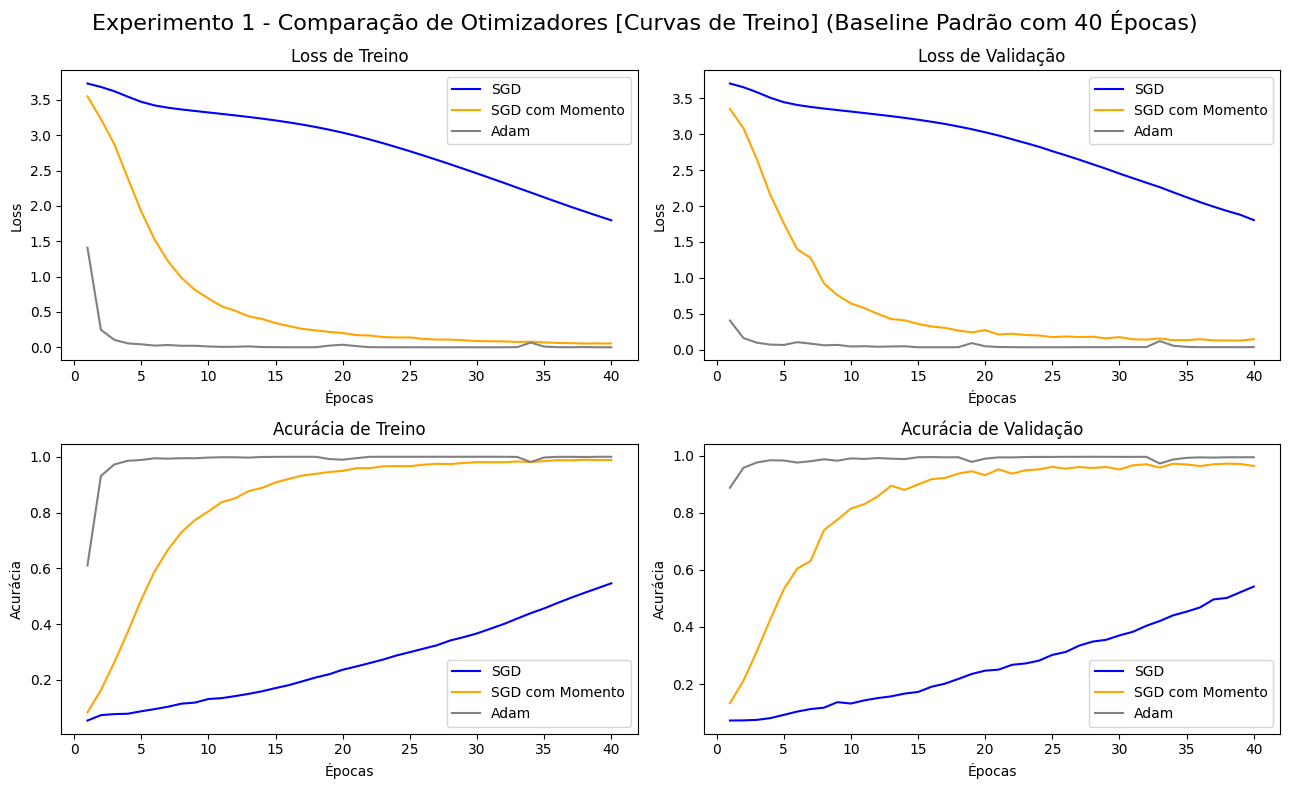

In [126]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
epochs = range(1, NUM_EPOCHS + 1)
colors = {'sgd': 'blue', 'sgd_momentum': 'orange', 'adam': 'gray'}
labels = {'sgd': 'SGD', 'sgd_momentum': 'SGD com Momento', 'adam': 'Adam'}

for name, r in all_results.items():
    axes[0,0].plot(epochs, r["history"]["train_loss"], label=labels[name], color=colors[name])
    axes[0,0].set_title("Loss de Treino")
    axes[0,0].set_xlabel("Épocas")
    axes[0,0].set_ylabel("Loss")
    axes[0,0].legend()

for name, r in all_results.items():
    axes[0,1].plot(epochs, r["history"]["val_loss"], label=labels[name], color=colors[name])
    axes[0,1].set_title("Loss de Validação")
    axes[0,1].set_xlabel("Épocas")
    axes[0,1].set_ylabel("Loss")
    axes[0,1].legend()

for name, r in all_results.items():
    axes[1,0].plot(epochs, r["history"]["train_acc"], label=labels[name], color=colors[name])
    axes[1,0].set_title("Acurácia de Treino")
    axes[1,0].set_xlabel("Épocas")
    axes[1,0].set_ylabel("Acurácia")
    axes[1,0].legend()

for name, r in all_results.items():
    axes[1,1].plot(epochs, r["history"]["val_acc"], label=labels[name], color=colors[name])
    axes[1,1].set_title("Acurácia de Validação")
    axes[1,1].set_xlabel("Épocas")
    axes[1,1].set_ylabel("Acurácia")
    axes[1,1].legend()

plt.suptitle("Experimento 1 - Comparação de Otimizadores [Curvas de Treino] (Baseline Padrão com 40 Épocas)", fontsize=16)
plt.tight_layout()
plt.savefig("figs/exp1_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 10. Avaliando Resultados no Conjunto de Teste

In [133]:
test_results = {}

for name, r in all_results.items():
    model = EHMNet().to(device)
    model.load_state_dict(torch.load(r["checkpoint_path"]))
    model.eval()

    ytrue, ypred = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            pred = model(images).argmax(1).cpu().numpy()
            ytrue.append(labels.numpy())
            ypred.append(pred)

    ytrue = np.concatenate(ytrue)
    ypred = np.concatenate(ypred)
    per_class_acc = per_class_accuracy(ytrue, ypred)
    global_acc = float((ypred == ytrue).mean())
    macro_acc = float(per_class_acc.mean())

    test_results[name] = {
        "ytrue": ytrue,
        "ypred": ypred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc
    }

    print(f"{name}:")
    print(f"  Acurácia Global: {global_acc:.4f}")
    print(f"  Acurácia Macro: {macro_acc:.4f}\n")

sgd:
  Acurácia Global: 0.4394
  Acurácia Macro: 0.0731

sgd_momentum:
  Acurácia Global: 0.7781
  Acurácia Macro: 0.0919

adam:
  Acurácia Global: 0.9194
  Acurácia Macro: 0.1375



### 10. Comparando Matriz de Confusão

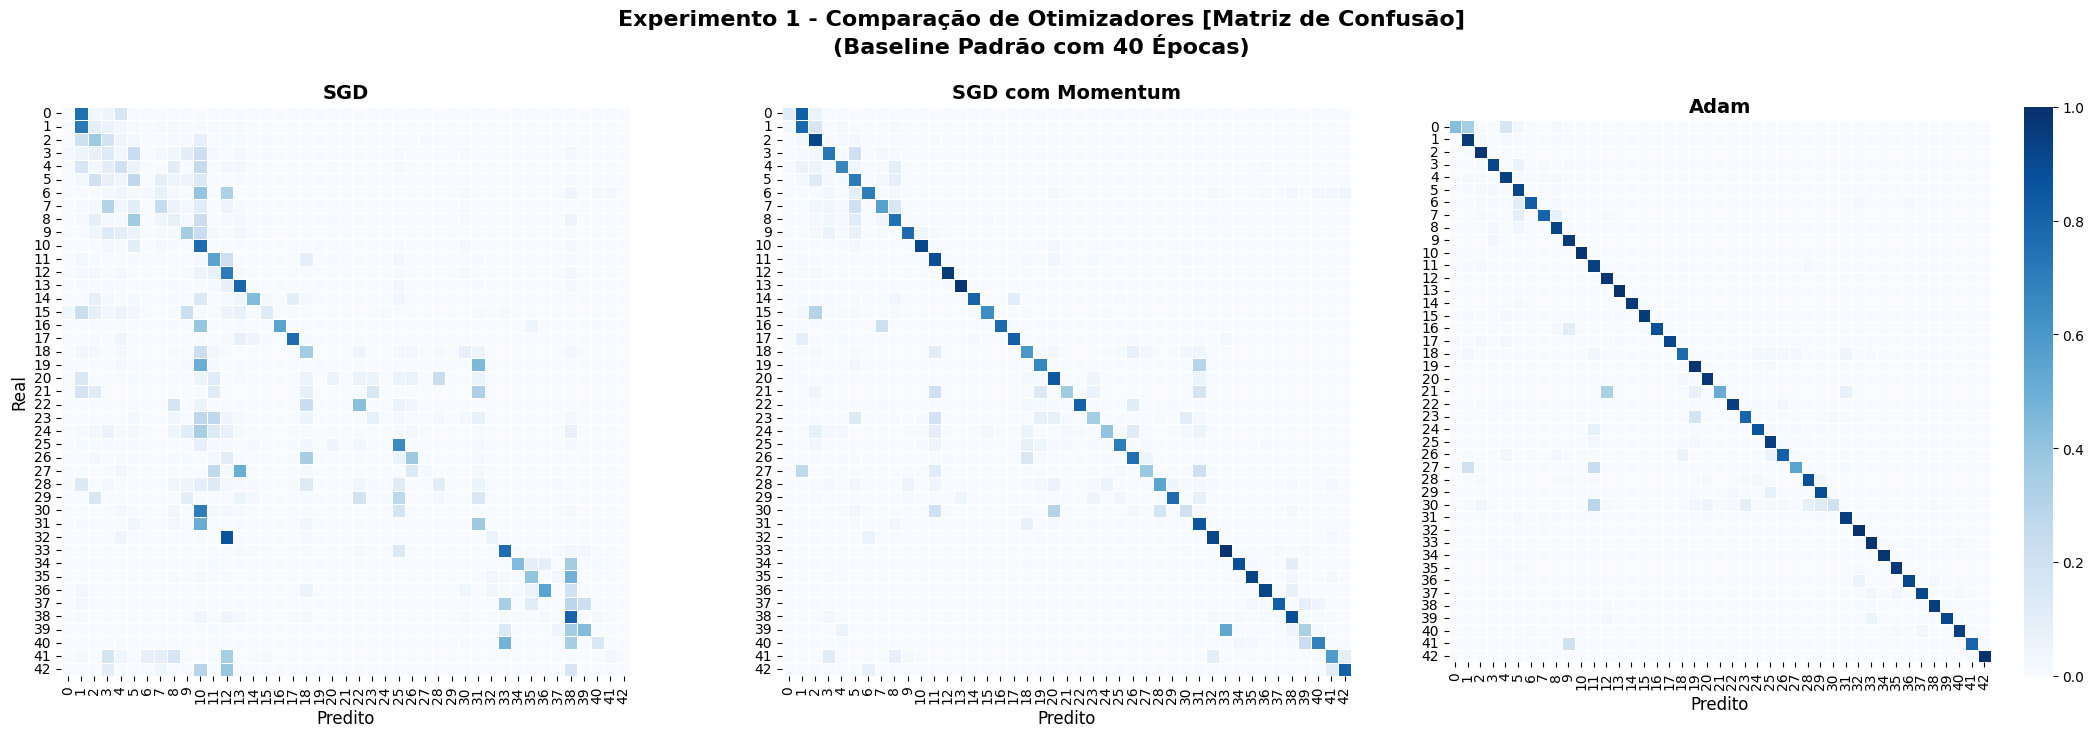

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
cm = {k: get_confusion_matrix(test_loader, r["model"], device).cpu().numpy() for k, r in all_results.items()}
labels = {"sgd": "SGD", "sgd_momentum": "SGD com Momentum", "adam": "Adam"}

for i, (name, r) in enumerate(all_results.items()):
    cm_norm = cm[name].astype(float) / cm[name].sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=False,
        xticklabels=np.arange(NUM_CLASSES),
        yticklabels=np.arange(NUM_CLASSES),
        ax=axes[i],
        cmap="Blues",
        cbar=i == 2,
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor="white",
        square=True,
    )
    axes[i].set_title(f"{labels[name]}", fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Predito", fontsize=12)
    axes[i].set_ylabel("Real" if i == 0 else "", fontsize=12)
    axes[i].tick_params(labelsize=10)

plt.suptitle(
    "Experimento 1 - Comparação de Otimizadores [Matriz de Confusão]\n(Baseline Padrão com 40 Épocas)",
    fontsize=16, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("figs/exp1_cm.png", dpi=150, bbox_inches="tight")
plt.show()

### 11. Comparando Acurácia por Classe

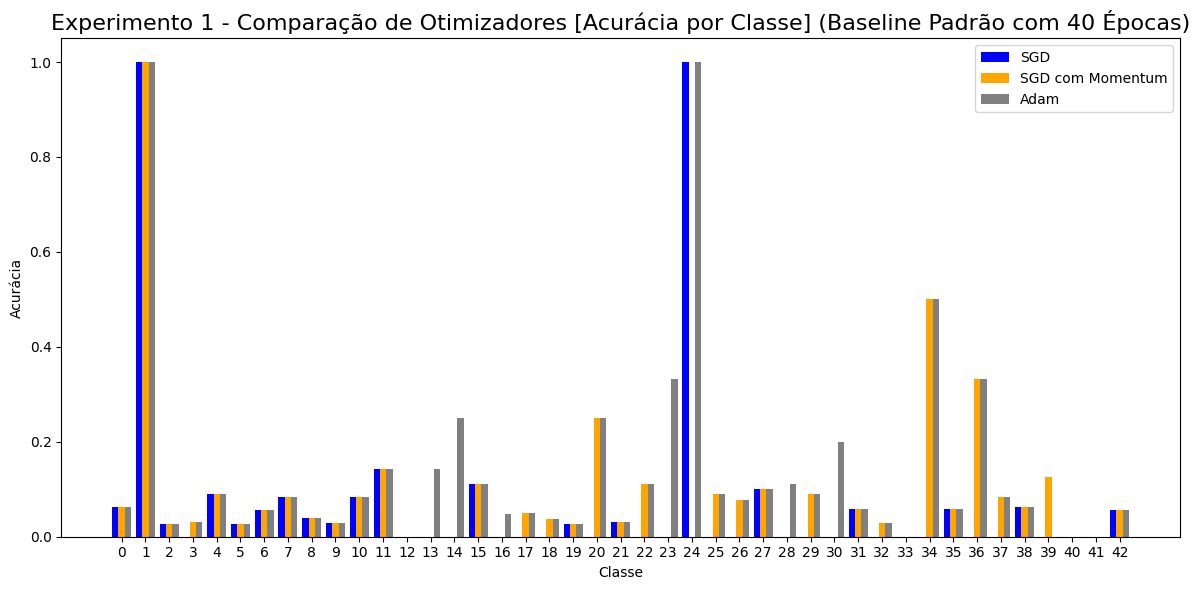

In [138]:
fig, ax = plt.subplots(figsize=(12, 6))
labels = {"sgd": "SGD", "sgd_momentum": "SGD com Momentum", "adam": "Adam"}
colors = {"sgd": "blue", "sgd_momentum": "orange", "adam": "gray"}
n_series = len(test_results)
width = 0.8 / n_series
x = np.arange(NUM_CLASSES)

for i, (name, r) in enumerate(test_results.items()):
    offset = (i - (n_series - 1) / 2) * width
    ax.bar(
        x + offset,
        r["per_class_acc"],
        width=width,
        label=labels[name],
        color=colors[name]
    )

    ax.set_xlabel("Classe")
    ax.set_ylabel("Acurácia")
    ax.set_title("Experimento 1 - Comparação de Otimizadores [Acurácia por Classe] (Baseline Padrão com 40 Épocas)", fontsize=16)
    ax.set_xticks(x)
    ax.legend()

plt.tight_layout()
plt.savefig("figs/exp1_acc_by_class.png", dpi=150, bbox_inches="tight")
plt.show()